In [6]:
import torch
import math
import json
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# 检查设备
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [5]:
MODEL_PATH = "Qwen/Qwen3-8B"  # 替换为你的本地路径

print("正在加载模型...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH, 
    torch_dtype=torch.bfloat16, 
    device_map=device,
    trust_remote_code=True
)
model.eval()

num_layers = model.config.num_hidden_layers
print(f"✅ 模型加载完毕！总层数: {num_layers}")

正在加载模型...


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

✅ 模型加载完毕！总层数: 36


In [7]:
# 这里替换为你刚才保存数据的确切路径
DATA_PATH = "/home/bev/disk4/haoxuan/SpeculativeDecoding/pruningAnalysis/calibration_data/wikitext_calibration_1000.json"

print(f"正在从本地加载 Wikitext-2 测试集: {DATA_PATH} ...")

# 1. 加载本地 JSON
with open(DATA_PATH, "r", encoding="utf-8") as f:
    calibration_texts = json.load(f)

# 2. 把所有文本块拼接成一条超长文本，模拟连续不断的自然语言流
full_text = " \n ".join(calibration_texts)

# 3. 将整个文本 Tokenize
print("正在进行 Tokenization，这可能需要几秒钟...")
encodings = tokenizer(full_text, return_tensors="pt")
total_tokens = encodings.input_ids.size(1)

print(f"总计获得 Token 数量: {total_tokens}")

# 4. 截取前 20 个 block (每个 block 2048 个 token) 来测试
stride = 2048
max_blocks = 20  # 如果你的显卡跑得快，想测得更准，可以把这里调大到 50 或 100
test_blocks = []

for i in range(0, min(total_tokens - stride, stride * max_blocks), stride):
    block = {
        "input_ids": encodings.input_ids[:, i : i + stride].to(device),
        "labels": encodings.input_ids[:, i : i + stride].to(device) # Causal LM 的标签就是输入本身
    }
    test_blocks.append(block)

print(f"✅ 准备了 {len(test_blocks)} 个数据块，每个包含 {stride} 个 Token，用于 PPL 测试。")

正在从本地加载 Wikitext-2 测试集: /home/bev/disk4/haoxuan/SpeculativeDecoding/pruningAnalysis/calibration_data/wikitext_calibration_1000.json ...
正在进行 Tokenization，这可能需要几秒钟...


Token indices sequence length is longer than the specified maximum sequence length for this model (488231 > 131072). Running this sequence through the model will result in indexing errors


总计获得 Token 数量: 488231
✅ 准备了 20 个数据块，每个包含 2048 个 Token，用于 PPL 测试。


In [8]:
def calculate_ppl(eval_model, blocks):
    total_loss = 0.0
    
    with torch.no_grad():
        for block in blocks:
            # 前向传播，模型会自动根据 input_ids 和 labels 计算交叉熵 Loss
            outputs = eval_model(input_ids=block["input_ids"], labels=block["labels"])
            total_loss += outputs.loss.item()
            
    # 计算平均 Loss 并转换为 PPL
    avg_loss = total_loss / len(blocks)
    ppl = math.exp(avg_loss)
    return ppl

print("✅ PPL 计算函数定义完成！")

✅ PPL 计算函数定义完成！


In [9]:
print("正在计算 Baseline PPL (完整 36 层)...")
baseline_ppl = calculate_ppl(model, test_blocks)
print(f"🎯 Baseline PPL: {baseline_ppl:.4f}")
print("（记住这个分数，剪掉某层后，PPL 比这个高出越多，说明那一层越不能剪！）")

正在计算 Baseline PPL (完整 36 层)...
🎯 Baseline PPL: 10.6369
（记住这个分数，剪掉某层后，PPL 比这个高出越多，说明那一层越不能剪！）


In [10]:
# 记录每一层被剪掉后的 PPL 变化
layer_ppl_degradations = {}

print("🚀 开始逐层破坏性测试...")

for layer_idx in tqdm(range(num_layers), desc="Testing Layers"):
    # 1. 暴力拔出第 layer_idx 层
    removed_layer = model.model.layers.pop(layer_idx)
    
    # 2. 此时模型只有 35 层了！测试它现在的 PPL
    degraded_ppl = calculate_ppl(model, test_blocks)
    
    # 3. 计算 PPL 恶化程度 (差值)
    degradation = degraded_ppl - baseline_ppl
    layer_ppl_degradations[layer_idx + 1] = degradation # 用 1-based 索引记录，方便人类阅读
    
    # 4. 测试完毕，把那一层原封不动地插回原来的位置
    model.model.layers.insert(layer_idx, removed_layer)

print("✅ 所有层的破坏性测试完成！")

🚀 开始逐层破坏性测试...


Testing Layers:   0%|          | 0/36 [00:00<?, ?it/s]

✅ 所有层的破坏性测试完成！


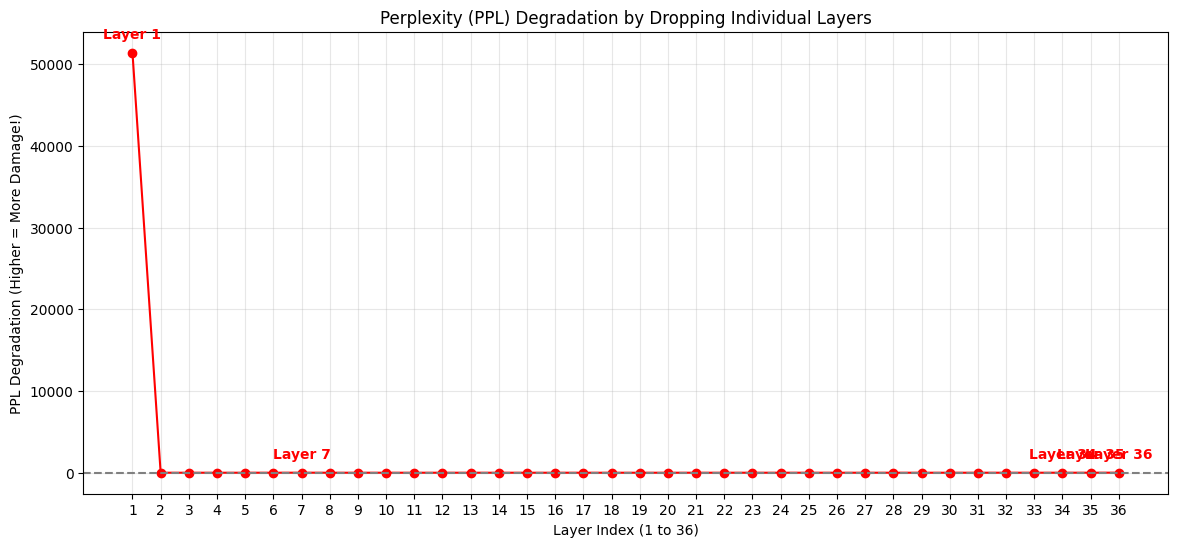

In [16]:
# 提取数据准备画图
layers = list(layer_ppl_degradations.keys())
degradations = list(layer_ppl_degradations.values())

# 绘制 PPL 恶化曲线
plt.figure(figsize=(14, 6))
plt.plot(layers, degradations, marker='o', linestyle='-', color='r')
plt.axhline(y=0, color='gray', linestyle='--') # 画一条零基准线
plt.title("Perplexity (PPL) Degradation by Dropping Individual Layers")
plt.xlabel("Layer Index (1 to 36)")
plt.ylabel("PPL Degradation (Higher = More Damage!)")
plt.grid(True, alpha=0.3)
plt.xticks(layers)

# 标出恶化最严重的前 5 层（绝对不能碰的层）
top_vital_layers = sorted(layer_ppl_degradations.items(), key=lambda x: x[1], reverse=True)[:5]
for layer, deg in top_vital_layers:
    plt.annotate(f"Layer {layer}", (layer, deg), textcoords="offset points", xytext=(0,10), ha='center', color='red', weight='bold')

plt.show()


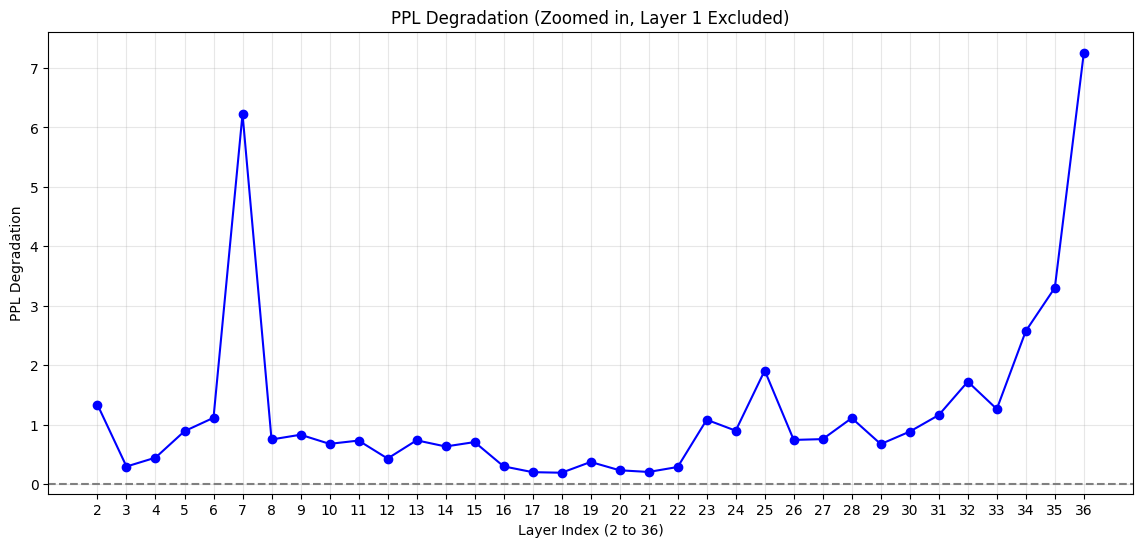

In [17]:
# 忽略掉最离谱的第1层，重新画图看看细节
filtered_layers = layers[1:] # 切片去掉第一个元素
filtered_degs = degradations[1:]

plt.figure(figsize=(14, 6))
plt.plot(filtered_layers, filtered_degs, marker='o', linestyle='-', color='b')
plt.axhline(y=0, color='gray', linestyle='--')
plt.title("PPL Degradation (Zoomed in, Layer 1 Excluded)")
plt.xlabel("Layer Index (2 to 36)")
plt.ylabel("PPL Degradation")
plt.grid(True, alpha=0.3)
plt.xticks(filtered_layers)
plt.show()

In [18]:

# -----------------
# 最终剪枝建议生成
# -----------------
# 按 PPL 恶化程度从小到大排序 (恶化越小，越说明是冗余层)
sorted_by_degradation = sorted(layer_ppl_degradations.items(), key=lambda x: x[1])

# 选出恶化最小的 18 层作为剪枝目标
layers_to_prune_ppl = sorted([layer for layer, deg in sorted_by_degradation[:18]])
layers_to_keep_ppl = sorted([layer for layer, deg in sorted_by_degradation[18:]])

print("\n" + "="*50)
print("🎯 基于 PPL 破坏测试的 18 层剪枝推荐")
print("="*50)
print(f"建议剪除 (恶化最小的18层): {layers_to_prune_ppl}")
print(f"建议保留 (恶化最大的18层): {layers_to_keep_ppl}")
print("="*50)


🎯 基于 PPL 破坏测试的 18 层剪枝推荐
建议剪除 (恶化最小的18层): [3, 4, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 26, 29]
建议保留 (恶化最大的18层): [1, 2, 5, 6, 7, 9, 23, 24, 25, 27, 28, 30, 31, 32, 33, 34, 35, 36]
